# **Hungary GP 2025**

# Telemetry Analysis

In [29]:
# Imports
import sys
import importlib
sys.path.append("../..")

import Sliplib.slipload as sl
import Sliplib.selection as slipclassify
import Sliplib.GridSum as grid_sum
import Sliplib.plotting as slplot
import configuration.config as DATA

importlib.reload(slipclassify)
importlib.reload(grid_sum)

<module 'Sliplib.GridSum' from '/mnt/Windows/Projects_S1/ProjectSlipstream/2026_Hungary_GP/notebooks/../../Sliplib/GridSum.py'>

In [30]:
# Select GP and Load Session
session = sl.load_gp(2025,"Hungarian Grand Prix","Race")
session.load()

core           INFO 	Loading data for Hungarian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '63', '16', '14', '5', '18', '30', '1', '12', '6', '44', '27', '55', '23', '31', '22', '43', '10', '87']


In [31]:
# Extract Lap Data
R_Laps = session.laps
R_Laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:59:18.340000,NOR,4,0 days 00:01:30.120000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:31.396000,...,True,McLaren,0 days 00:57:47.946000,2025-08-03 13:03:06.040,1,5.0,False,,False,False
1,0 days 01:00:42.304000,NOR,4,0 days 00:01:23.964000,2.0,1.0,NaT,NaT,0 days 00:00:30.209000,0 days 00:00:30.346000,...,True,McLaren,0 days 00:59:18.340000,2025-08-03 13:04:36.434,1,5.0,False,,False,True
2,0 days 01:02:05.527000,NOR,4,0 days 00:01:23.223000,3.0,1.0,NaT,NaT,0 days 00:00:29.792000,0 days 00:00:30.097000,...,True,McLaren,0 days 01:00:42.304000,2025-08-03 13:06:00.398,1,4.0,False,,False,True
3,0 days 01:03:28.404000,NOR,4,0 days 00:01:22.877000,4.0,1.0,NaT,NaT,0 days 00:00:30.125000,0 days 00:00:29.665000,...,True,McLaren,0 days 01:02:05.527000,2025-08-03 13:07:23.621,1,4.0,False,,False,True
4,0 days 01:04:51.043000,NOR,4,0 days 00:01:22.639000,5.0,1.0,NaT,NaT,0 days 00:00:29.930000,0 days 00:00:29.672000,...,True,McLaren,0 days 01:03:28.404000,2025-08-03 13:08:46.498,1,4.0,False,,False,True


In [32]:
# Import Drivers
top_drivers = slipclassify.select_drivers(R_Laps,DATA.CONTENDERS)

# Test
top_drivers["VER"]

dict_keys(['HAD', 'HUL', 'ALB', 'COL', 'NOR', 'LAW', 'BEA', 'SAI', 'OCO', 'GAS', 'PIA', 'VER'])


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
560,0 days 00:59:20.588000,VER,1,0 days 00:01:32.368000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:32.379000,...,True,Red Bull Racing,0 days 00:57:47.946000,2025-08-03 13:03:06.040,1,9.0,False,,False,False
561,0 days 01:00:44.459000,VER,1,0 days 00:01:23.871000,2.0,1.0,NaT,NaT,0 days 00:00:30.079000,0 days 00:00:30.523000,...,True,Red Bull Racing,0 days 00:59:20.588000,2025-08-03 13:04:38.682,1,8.0,False,,False,True
562,0 days 01:02:08.269000,VER,1,0 days 00:01:23.810000,3.0,1.0,NaT,NaT,0 days 00:00:29.663000,0 days 00:00:30.650000,...,True,Red Bull Racing,0 days 01:00:44.459000,2025-08-03 13:06:02.553,1,7.0,False,,False,True
563,0 days 01:03:32.122000,VER,1,0 days 00:01:23.853000,4.0,1.0,NaT,NaT,0 days 00:00:29.601000,0 days 00:00:30.795000,...,True,Red Bull Racing,0 days 01:02:08.269000,2025-08-03 13:07:26.363,1,7.0,False,,False,True
564,0 days 01:04:55.935000,VER,1,0 days 00:01:23.813000,5.0,1.0,NaT,NaT,0 days 00:00:29.425000,0 days 00:00:30.834000,...,True,Red Bull Racing,0 days 01:03:32.122000,2025-08-03 13:08:50.216,1,7.0,False,,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625,0 days 02:28:55.845000,VER,1,0 days 00:01:21.161000,66.0,3.0,NaT,NaT,0 days 00:00:29.315000,0 days 00:00:28.906000,...,True,Red Bull Racing,0 days 02:27:34.684000,2025-08-03 14:32:52.778,1,9.0,False,,False,True
626,0 days 02:30:16.939000,VER,1,0 days 00:01:21.094000,67.0,3.0,NaT,NaT,0 days 00:00:29.261000,0 days 00:00:28.718000,...,True,Red Bull Racing,0 days 02:28:55.845000,2025-08-03 14:34:13.939,1,9.0,False,,False,True
627,0 days 02:31:38.215000,VER,1,0 days 00:01:21.276000,68.0,3.0,NaT,NaT,0 days 00:00:29.434000,0 days 00:00:28.845000,...,True,Red Bull Racing,0 days 02:30:16.939000,2025-08-03 14:35:35.033,1,9.0,False,,False,True
628,0 days 02:32:59.892000,VER,1,0 days 00:01:21.677000,69.0,3.0,NaT,NaT,0 days 00:00:29.626000,0 days 00:00:29.004000,...,True,Red Bull Racing,0 days 02:31:38.215000,2025-08-03 14:36:56.309,1,9.0,False,,False,True


In [33]:
# Pick the fastest Lap for each
fastest_data = slipclassify.pick_fastest_group(top_drivers)

# Test
fastest_data["NOR"]

Time                      0 days 02:15:43.363000
Driver                                       NOR
DriverNumber                                   4
LapTime                   0 days 00:01:19.918000
LapNumber                                   57.0
Stint                                        2.0
PitOutTime                                   NaT
PitInTime                                    NaT
Sector1Time               0 days 00:00:29.058000
Sector2Time               0 days 00:00:28.214000
Sector3Time               0 days 00:00:22.646000
Sector1SessionTime        0 days 02:14:52.522000
Sector2SessionTime        0 days 02:15:20.736000
Sector3SessionTime        0 days 02:15:43.382000
SpeedI1                                    274.0
SpeedI2                                    250.0
SpeedFL                                    252.0
SpeedST                                    288.0
IsPersonalBest                              True
Compound                                    HARD
TyreLife            

In [34]:
# Take out a Summary!
fast_sum = slipclassify.tel_fast_lap_summary(fastest_data.values())
fast_sum

,Driver,LapTime,Compound,TyreLife
0,HAD,1:20.802,HARD,15.0
1,HUL,1:20.013,MEDIUM,26.0
2,ALB,1:20.779,HARD,11.0
3,COL,1:20.827,HARD,2.0
4,NOR,1:19.918,HARD,27.0
5,LAW,1:20.457,HARD,16.0
6,BEA,1:21.989,HARD,7.0
7,SAI,1:19.790,MEDIUM,2.0
8,OCO,1:21.916,HARD,3.0
9,GAS,1:21.433,MEDIUM,14.0


## Telemetry Datas and Graphs

In [35]:
# Get Telemetry Datas
tel_dist_datas = slipclassify.tel_get_for_all(fastest_data)

# Test
tel_dist_datas["VER"]

,Date,RPM,Speed,nGear,Throttle,Brake,DRS,Source,Time,SessionTime,Distance
0,2025-08-03 14:11:24.005,11393.0,257.0,6,100.0,False,0,car,0 days 00:00:00.154000,0 days 02:06:05.911000,10.993889
1,2025-08-03 14:11:24.285,11576.0,259.0,6,100.0,False,0,car,0 days 00:00:00.434000,0 days 02:06:06.191000,31.138333
2,2025-08-03 14:11:24.525,10893.0,264.0,6,100.0,False,0,car,0 days 00:00:00.674000,0 days 02:06:06.431000,48.738333
3,2025-08-03 14:11:24.685,10634.0,265.0,6,100.0,False,0,car,0 days 00:00:00.834000,0 days 02:06:06.591000,60.516111
4,2025-08-03 14:11:24.884,10629.0,265.0,7,100.0,False,0,car,0 days 00:00:01.033000,0 days 02:06:06.790000,75.164722
...,...,...,...,...,...,...,...,...,...,...,...
300,2025-08-03 14:12:42.125,11024.0,233.0,5,100.0,False,0,car,0 days 00:01:18.274000,0 days 02:07:24.031000,4268.699722
301,2025-08-03 14:12:42.405,10708.0,237.0,6,100.0,False,0,car,0 days 00:01:18.554000,0 days 02:07:24.311000,4287.133056
302,2025-08-03 14:12:42.845,10987.0,246.0,6,100.0,False,0,car,0 days 00:01:18.994000,0 days 02:07:24.751000,4317.199722
303,2025-08-03 14:12:43.165,11164.0,251.0,6,100.0,False,0,car,0 days 00:01:19.314000,0 days 02:07:25.071000,4339.510833


### Plot - 1 (Distance vs Speed)
This part consists the comparision plots of all the contenders

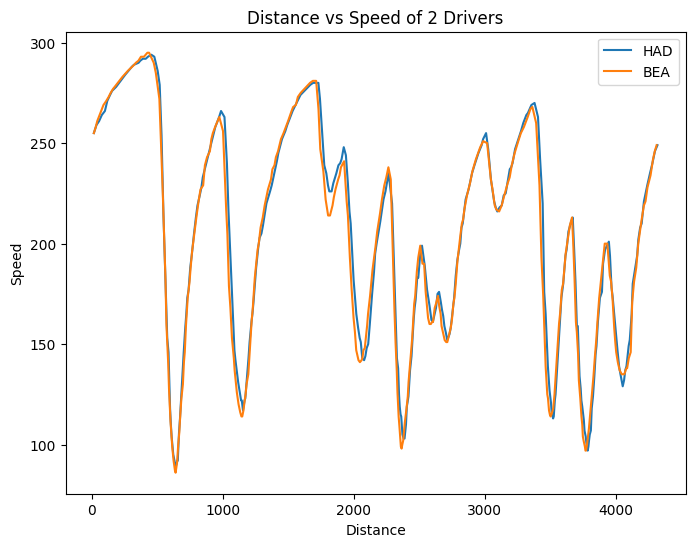

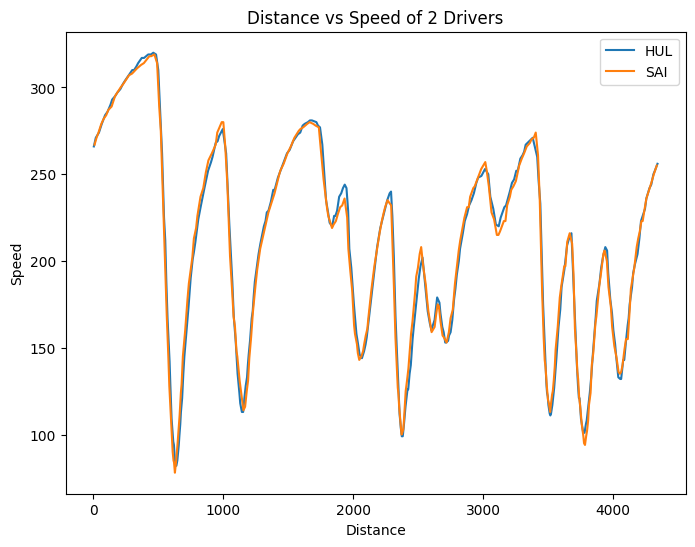

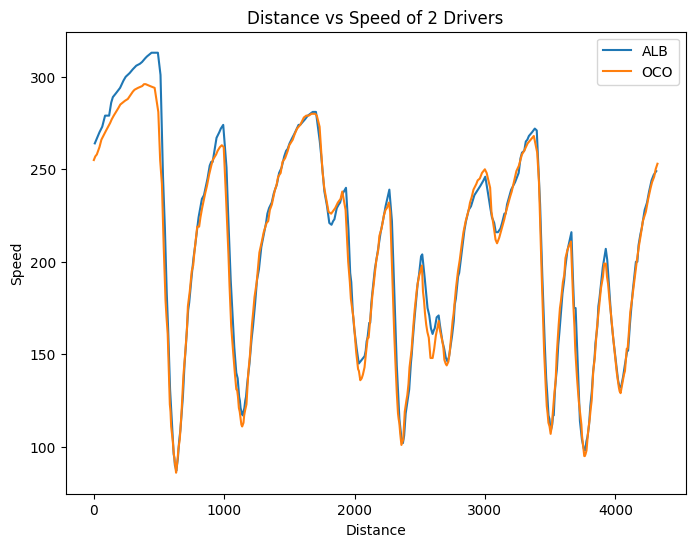

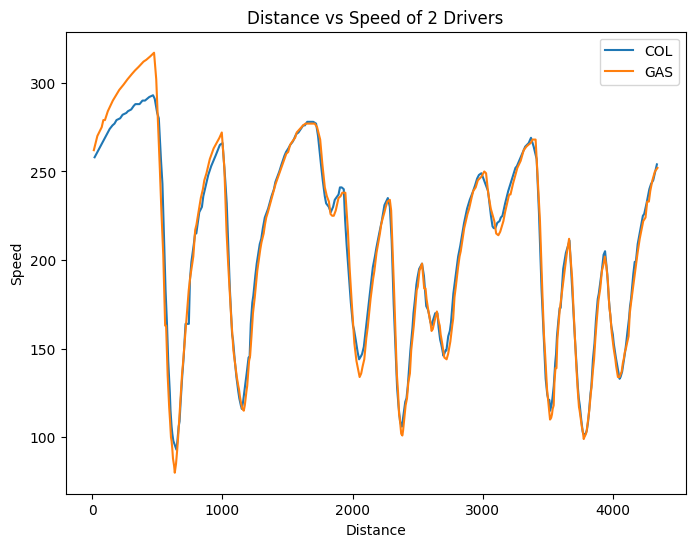

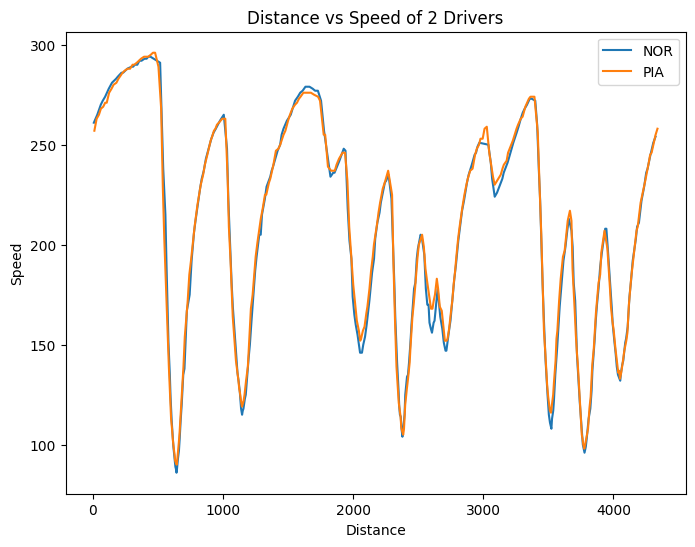

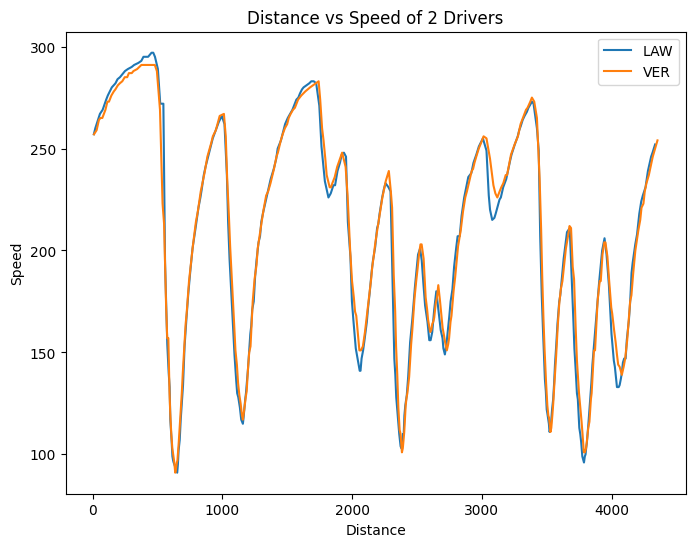

In [37]:
for pairs in DATA.RIVALS:
    slplot.plot_dist_speed([tel_dist_datas[pairs[0]],tel_dist_datas[pairs[1]]],pairs)

From the above Graph! Piastri Has an advantage! He has made the Fastest Lap among the Contenders!

### Plot - 2 (Distance vs Brake)

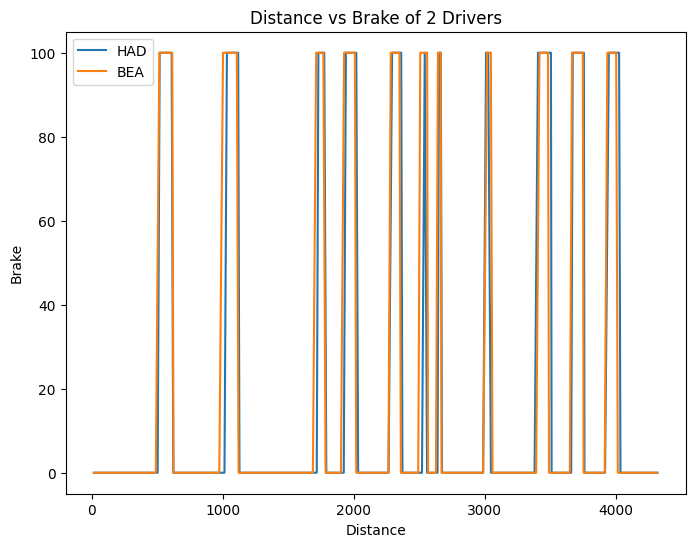

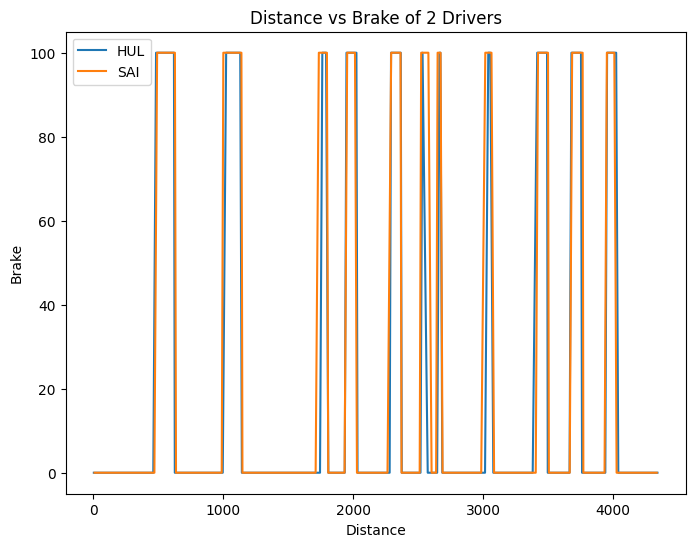

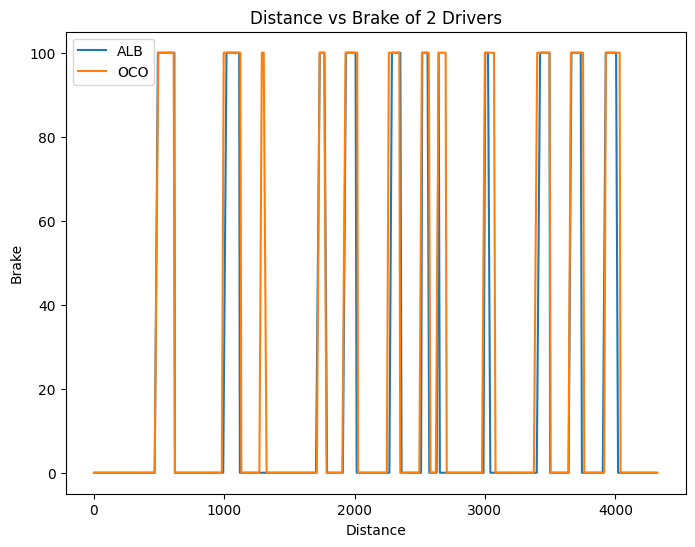

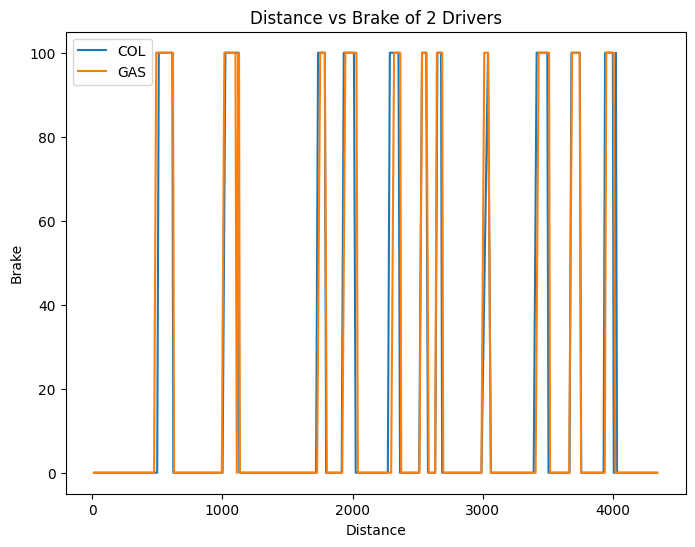

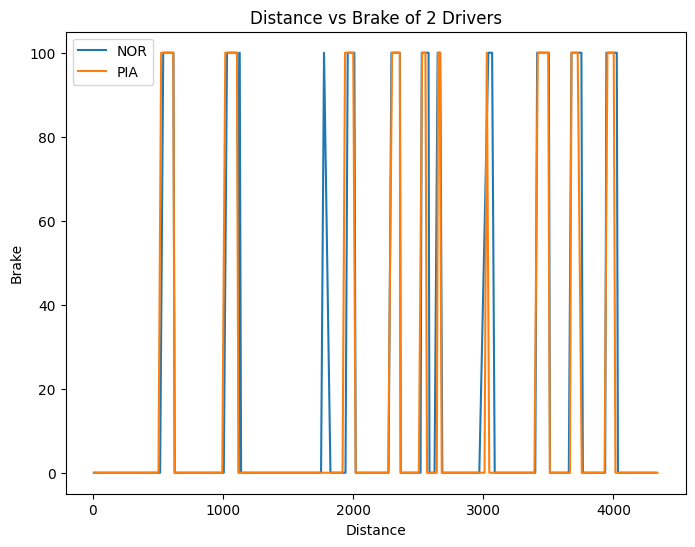

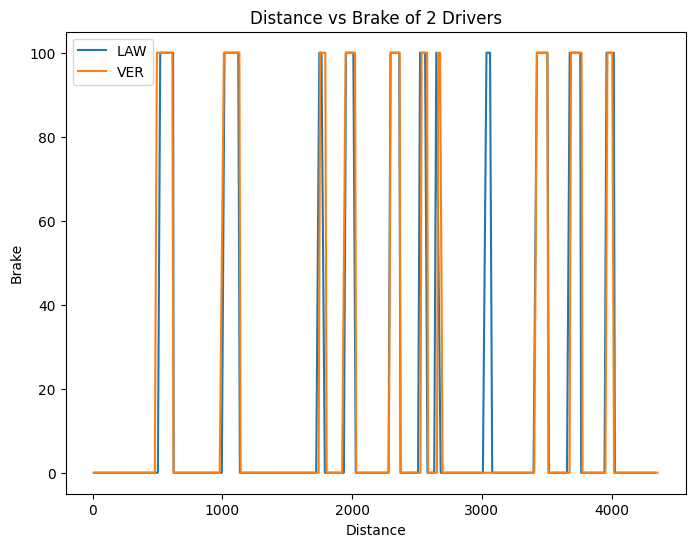

In [38]:
for pairs in DATA.RIVALS:
    slplot.plot_dist_brake([tel_dist_datas[pairs[0]],tel_dist_datas[pairs[1]]],pairs)

### Plot - 3 (Distance vs nGear)

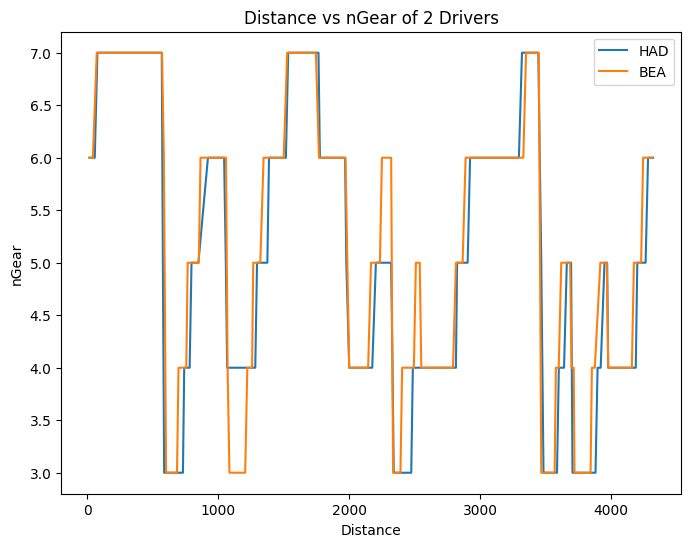

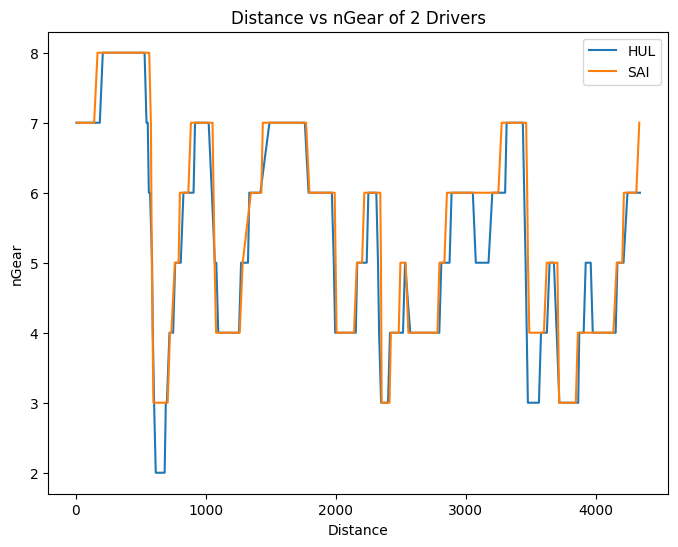

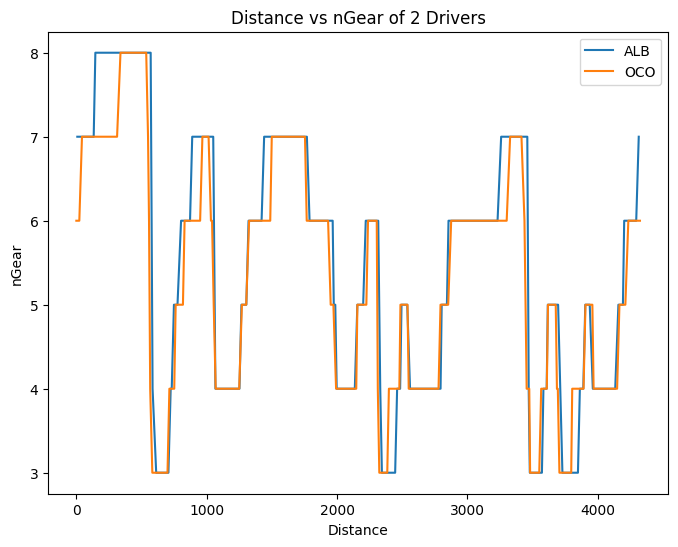

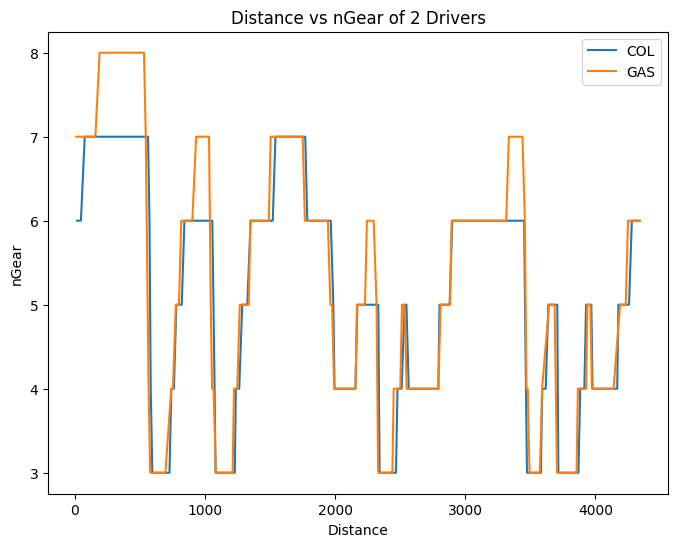

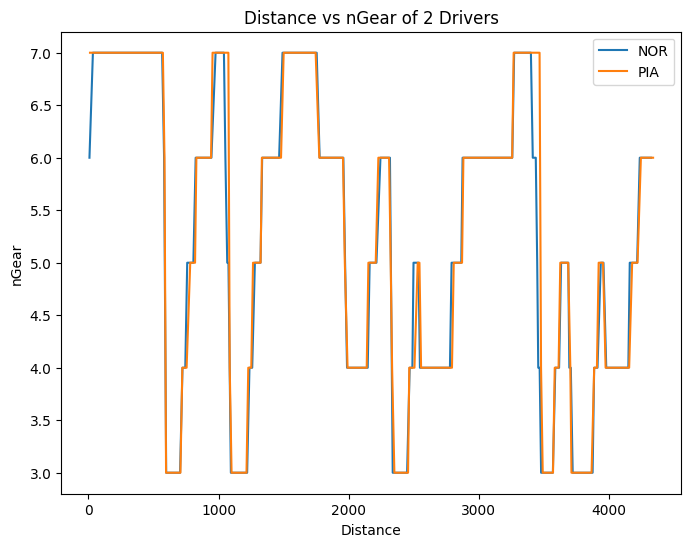

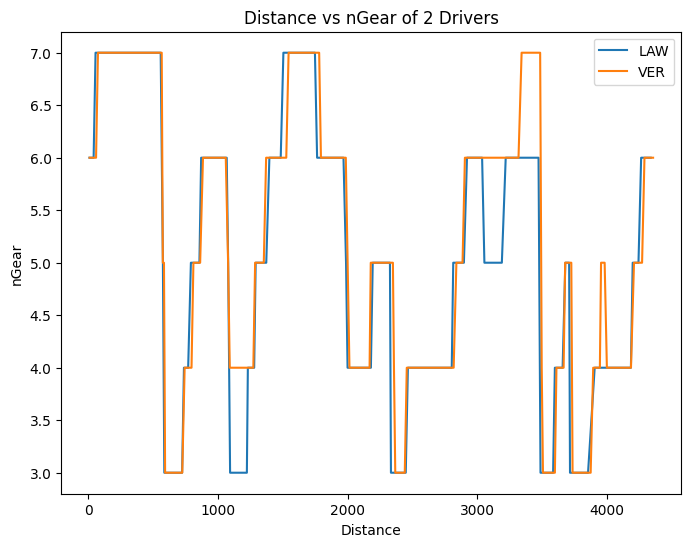

In [39]:
for pairs in DATA.RIVALS:
    slplot.plot_dist_ngear([tel_dist_datas[pairs[0]],tel_dist_datas[pairs[1]]],pairs)

### Plot - 4 (Distance vs RPM)

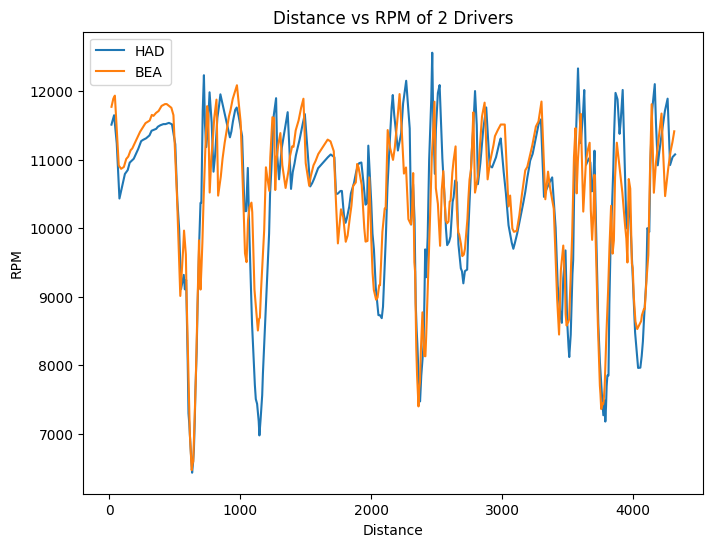

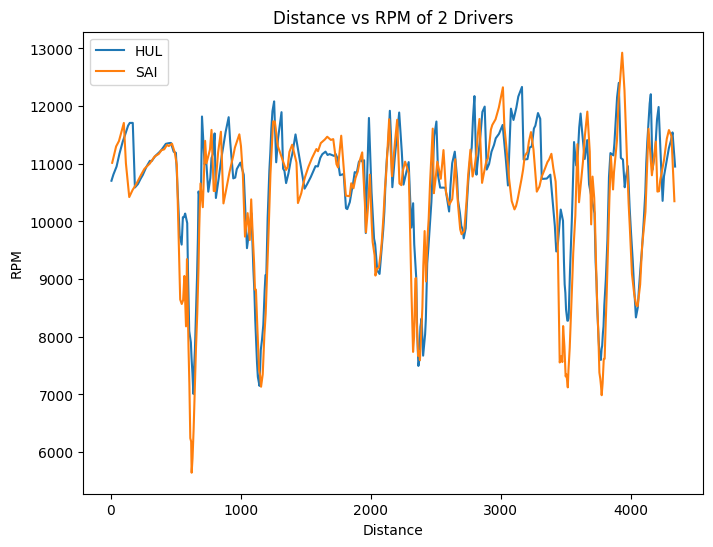

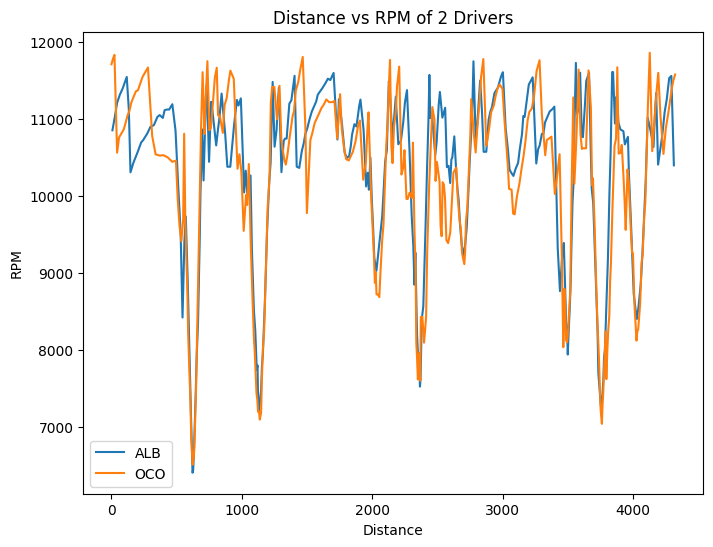

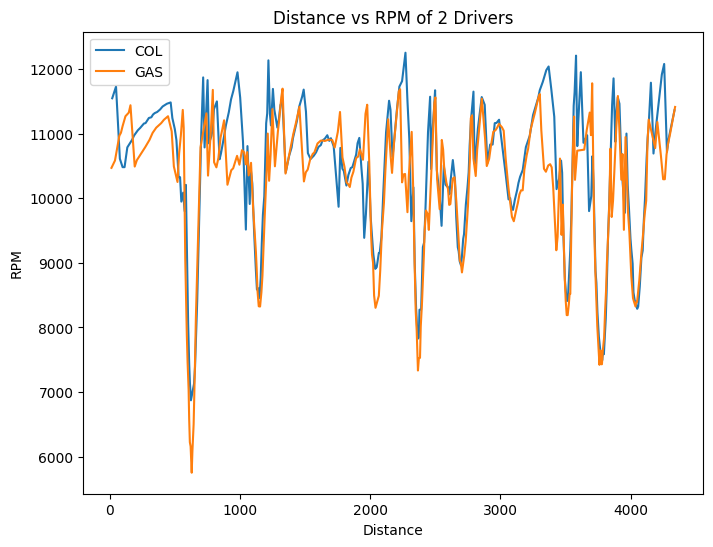

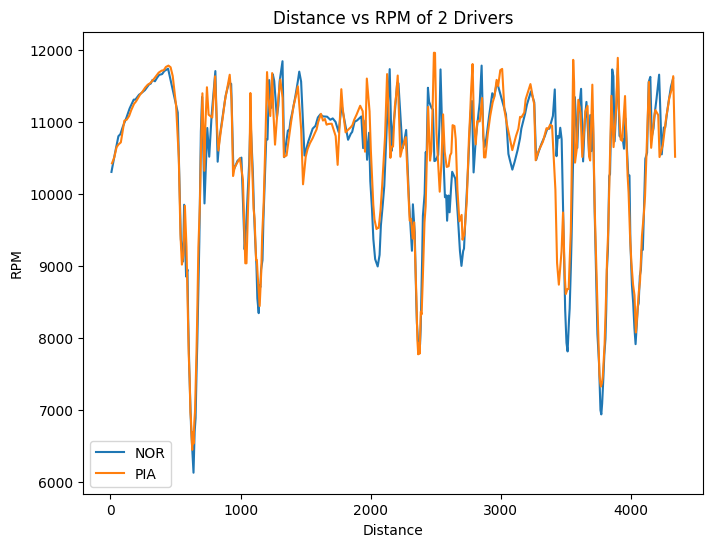

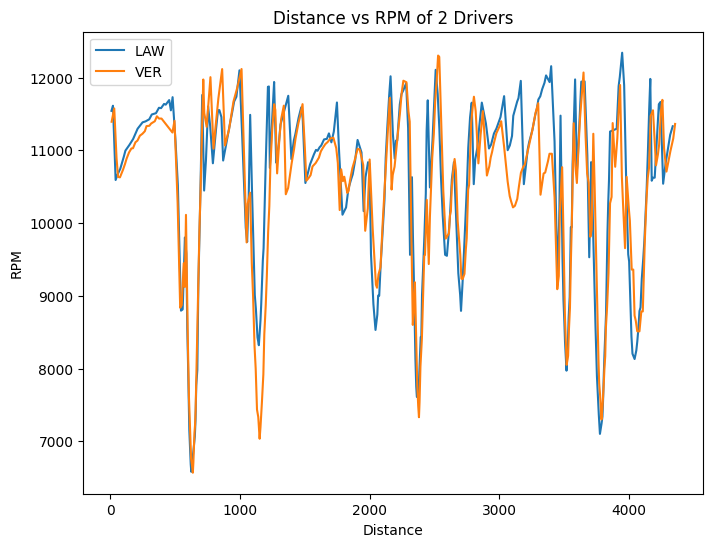

In [40]:
for pairs in DATA.RIVALS:
    slplot.plot_dist_rpms([tel_dist_datas[pairs[0]],tel_dist_datas[pairs[1]]],pairs)